In [171]:
%matplotlib inline
import sys
import yaml
from IPython.display import Code
import pcse
from datetime import datetime, timedelta
import pprint
import pandas as pd
import numpy as np
import matplotlib
matplotlib.style.use("ggplot")
import matplotlib.pyplot as plt
import os
import xarray as xr
import pickle
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [172]:
#convert pickle to netcdf
def wso_cube_from_results(all_results):
    # 1) Normalize and collect unique coords
    for d in all_results:
        df = d["outputs_df"]
        df["day"] = pd.to_datetime(df["day"])
    days = pd.to_datetime(sorted(set(pd.concat([d["outputs_df"]["day"] for d in all_results]).unique())))
    tsteps = sorted(set(d["Tstep"] for d in all_results))
    ppsteps = sorted(set(d["PPstep"] for d in all_results))

    # 2) Initialize empty DataArray (day, Tstep, PPstep)
    WSO = xr.DataArray(
        np.full((len(days), len(ppsteps), len(tsteps)), np.nan, dtype=float),
        dims=("day", "PPstep", "Tstep"),
        coords={"day": days, "PPstep": ppsteps, "Tstep": tsteps},
        name="WSO",
    )

    # 3) Fill values per (Tstep, PPstep)
    day_index = pd.Index(days)
    for d in all_results:
        T = d["Tstep"]
        P = d["PPstep"]
        df = d["outputs_df"].copy()
        df["day"] = pd.to_datetime(df["day"])
        df = df.set_index("day")

        # Align to master day index (reindex to avoid length mismatches)
        if "WSO" not in df.columns:
            continue  # skip if missing
        series = df["WSO"].reindex(day_index)

        # If there are duplicates for the same (T,P), last one wins by default
        WSO.loc[dict(Tstep=T, PPstep=P)] = series.values

    # 4) Return as Dataset for saving convenience
    return xr.Dataset({"WSO": WSO})

In [270]:
# Open data files
show_climate = True
title_plot1 = 'Jokioinen \n CO2 572ppm; Full Irrigation; RCP8.5 2041-2070' 
plot_name1 = "Jokioinen_Currentcultivar_CO2572ppm_AdaptedSD_WLmodel_RCP85_irrigationFULL.png"
title_plot2 = 'Jokioinen - low yield risk \n CO2 572ppm; Full Irrigation; RCP8.5 2041-2070' 
plot_name2 = "Jokioinen_Currentcultivar_CO2572ppm_AdaptedSD_WLmodel_RCP85_irrigationFULL_lowYieldRisk.png"

results_data_file = "all_results_SoilFIN_CLAY_1_CO2572.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB_IrrigationFULL.pkl"
results_base_file = "all_results_SoilFIN_CLAY_1_CO2422.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB_IrrigationRAINFED.pkl"

with open(results_data_file, "rb") as f:
   all_results =  pickle.load(f)

with open(results_base_file, "rb") as f:
   all_results_BASE =  pickle.load(f)

# Load CSV with climate model mean changes
# CSV has columns: model_name, t_change, pp_change
df_changes = pd.read_csv("methodology_outs/rcp85_2041_2070_meanChanges_JOK.csv")

In [271]:
wsoIRS = wso_cube_from_results(all_results)
wsoIRS_base = wso_cube_from_results(all_results_BASE)

WSO_max = wsoIRS['WSO']   # already has coords: day, PPstep, Tstep
max_per_year = WSO_max.groupby('day.year').max() # Group by year and take the maximum

WSO_max_base = wsoIRS_base['WSO']   # already has coords: day, PPstep, Tstep
max_per_year_base = WSO_max_base.groupby('day.year').max() # Group by year and take the maximum

In [272]:
# estimate the % of cases where the max WSO per year was less than 5000 kg/
low_wso = max_per_year < 5000
percentage_below_5000 = low_wso.mean(dim="year") * 100

low_wso_base = max_per_year_base < 5000
percentage_below_5000_base = low_wso_base.mean(dim="year") * 100

dif2 = (percentage_below_5000 - percentage_below_5000_base.sel(PPstep=0, Tstep=0)) / percentage_below_5000_base.sel(PPstep=0, Tstep=0) * 100
data2 = dif2

Text(0.5, 1.0, 'Maximum WSO per year for Jokioinen, Dif = 41.14%')

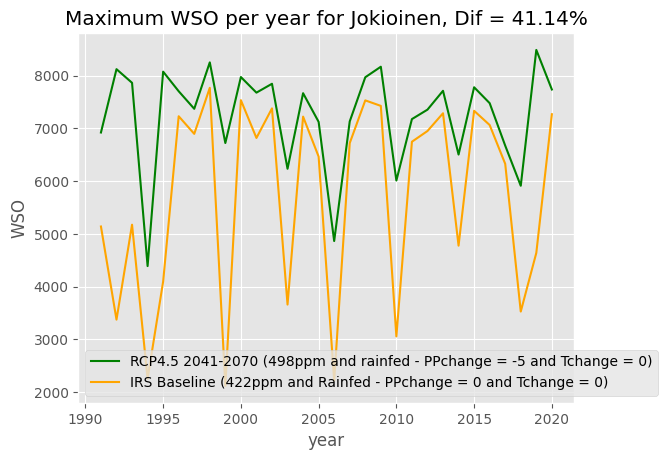

In [246]:
#just a test to compare with the surface plot
b = max_per_year.sel(PPstep=-5, Tstep=0)
b.plot(label='RCP4.5 2041-2070 (498ppm and rainfed - PPchange = -5 and Tchange = 0)', color='green')
#max_per_year.sel(PPstep=-5, Tstep=0).plot(label='IRS RCP4.5 2041-2070', color='blue')
a = max_per_year_base.sel(PPstep=0, Tstep=0)
a.plot(label='IRS Baseline (422ppm and Rainfed - PPchange = 0 and Tchange = 0)', color='orange')
dif = (b - a) / a * 100
dif2 = dif.mean(dim='year',  skipna=True)
plt.legend()
plt.title(f'Maximum WSO per year for Jokioinen, Dif = {dif2.values:.2f}%')

Text(0.5, 1.0, 'Maximum WSO per year for Jokioinen, Dif = 41.14%')

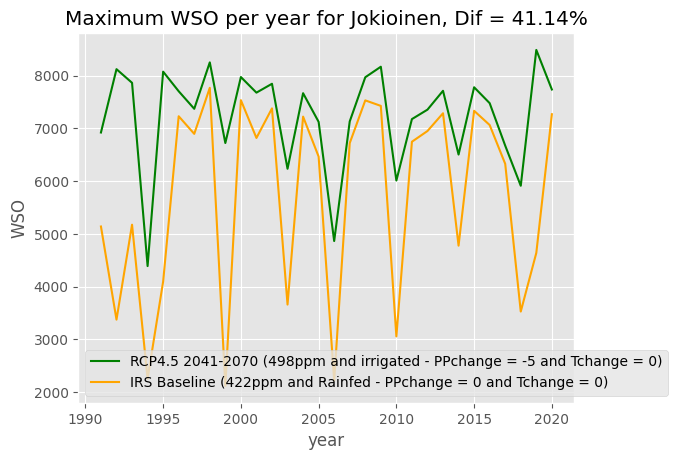

In [ ]:
#just a test to compare with the surface plot
results_data_file2 = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB_IrrigationSI.pkl"
with open(results_data_file2, "rb") as f:
   all_results2 =  pickle.load(f)
wsoIRS2 = wso_cube_from_results(all_results2)

WSO_max2 = wsoIRS2['WSO']   # already has coords: day, PPstep, Tstep
max_per_year2 = WSO_max2.groupby('day.year').max() # Group by year and take the maximum

b = max_per_year2.sel(PPstep=-5, Tstep=0)
b.plot(label='RCP4.5 2041-2070 (498ppm and irrigated - PPchange = -5 and Tchange = 0)', color='green')
#max_per_year.sel(PPstep=-5, Tstep=0).plot(label='IRS RCP4.5 2041-2070', color='blue')
a = max_per_year_base.sel(PPstep=0, Tstep=0)
a.plot(label='IRS Baseline (422ppm and Rainfed - PPchange = 0 and Tchange = 0)', color='orange')
dif = (b - a) / a * 100
dif2 = dif.mean(dim='year',  skipna=True)
plt.legend()
plt.title(f'Maximum WSO per year for Jokioinen, Dif = {dif2.values:.2f}%')

In [273]:
# Calculate percentage difference from baseline (0,0)
#percentage difference of the years that are not 0 in the baseline and in the future scenario

diff = (max_per_year - max_per_year_base.sel(PPstep=0, Tstep=0))/max_per_year_base.sel(PPstep=0, Tstep=0) * 100.0
# 2. Ensure both max_per_year and base max are non-zero 
diff = diff.where( 
    np.isfinite(diff) & 
    (max_per_year != 0) & 
    (max_per_year_base.sel(PPstep=0, Tstep=0) != 0) 
    )
#diff = diff.dropna(dim='year', how='all')  # Drop years with all NaNs
data = diff.mean(dim='year',  skipna=True)
#take the median of the diff
#data = diff.median(dim='year')


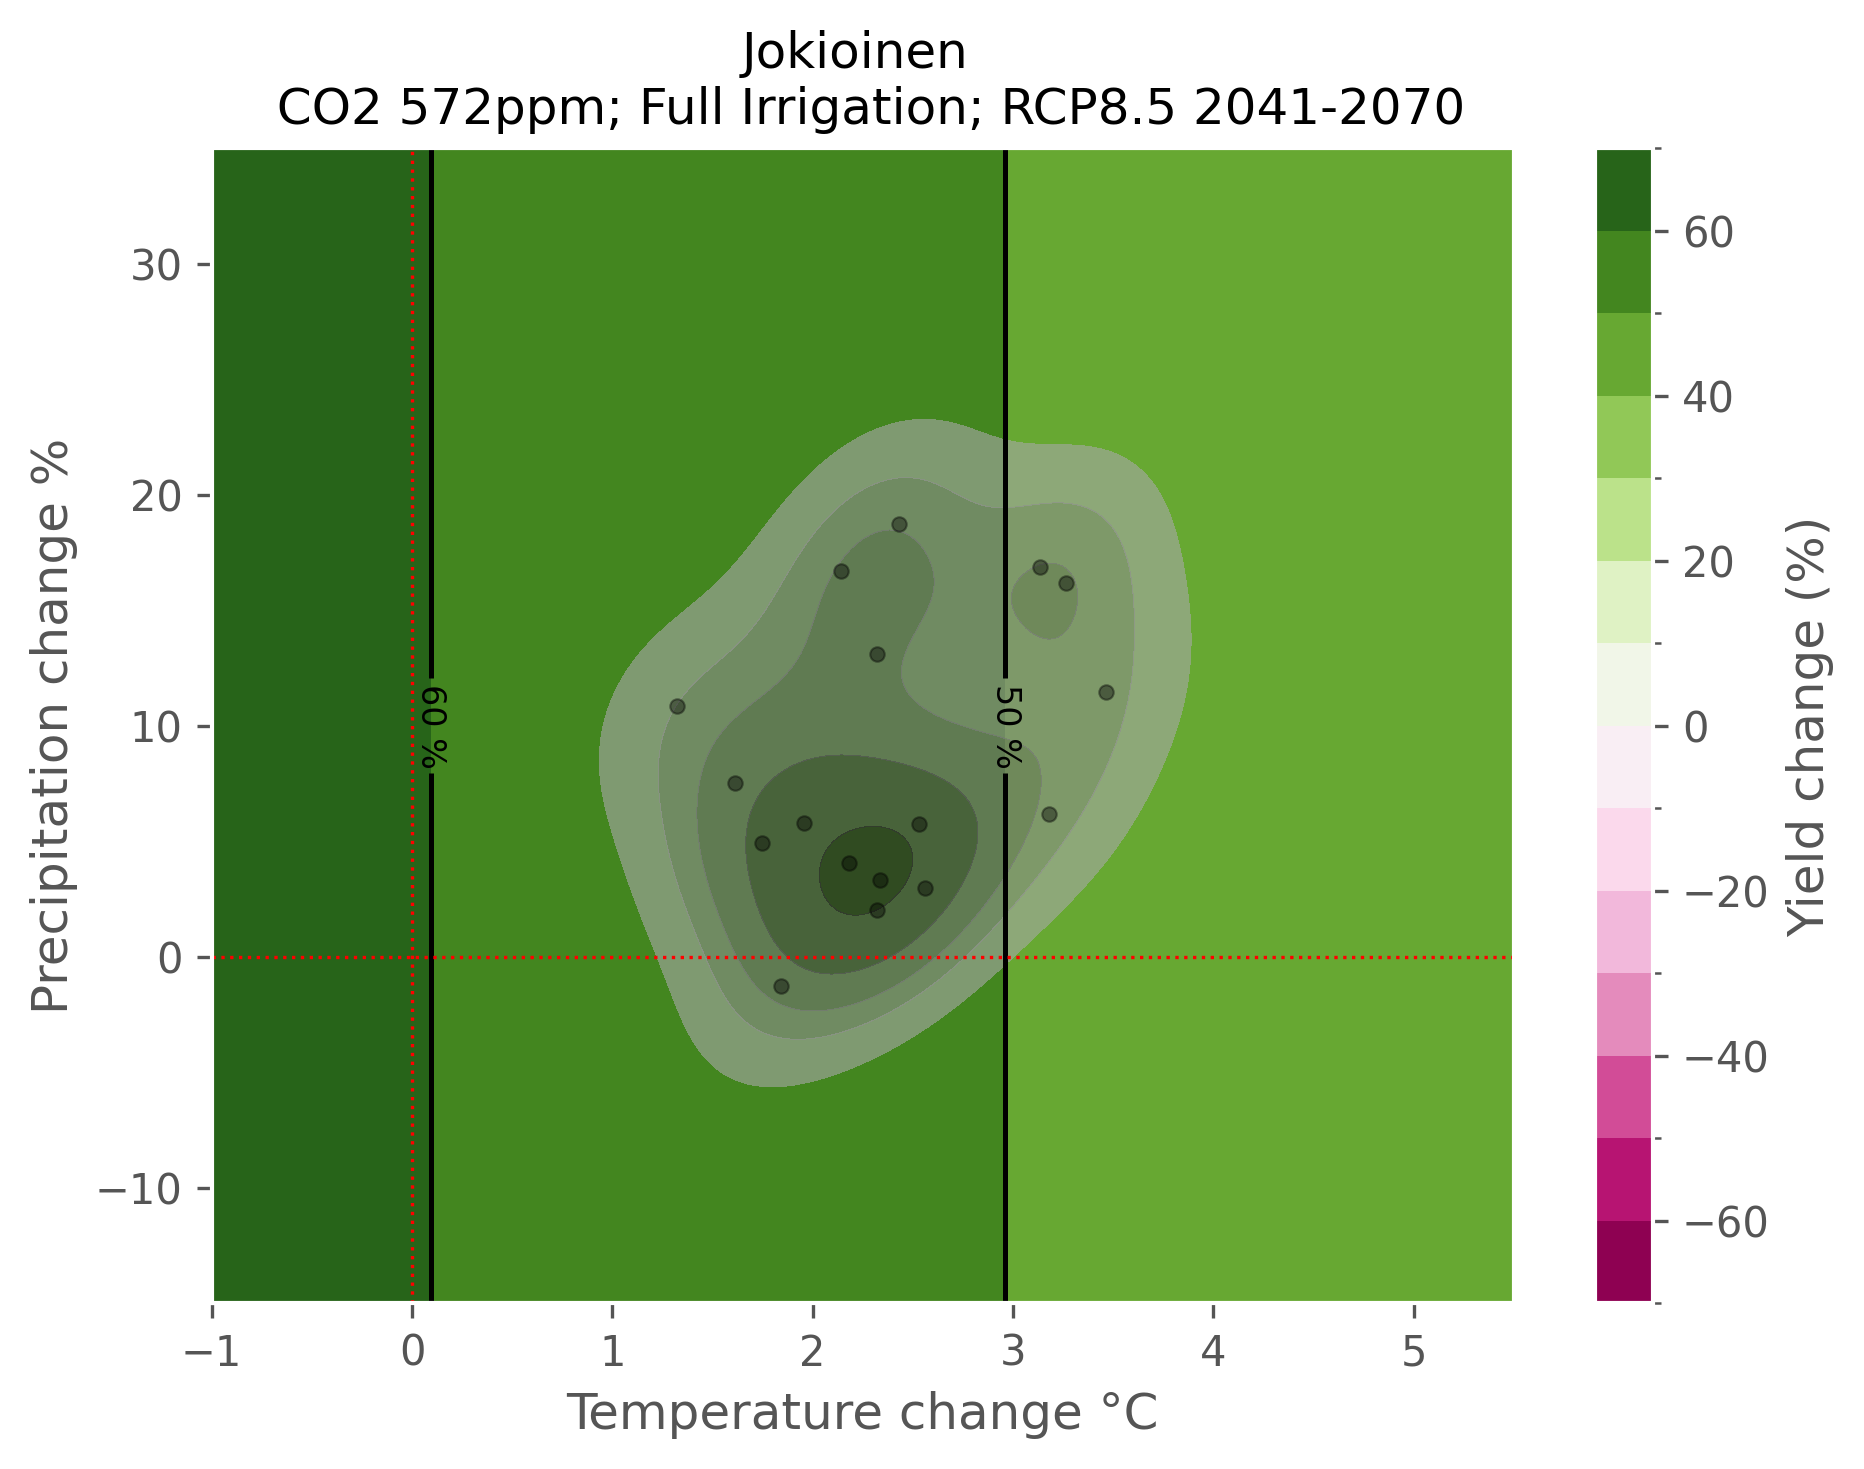

In [274]:
# Filled contour plot (smooth shading)
plt.figure(figsize=(7,5), dpi = 300)
contourf = data.plot.contourf(levels=15, cmap='PiYG', 
                              vmin = -70,
                              vmax = +70, #vmax= 7900,
                              cbar_kwargs={'label': 'Yield change (%)'})  # more levels = smoother
# Define contour levels
levels = np.linspace(-70, 70, 15)

# Default all black
colors = ["black"] * len(levels)

# If 0 is in levels, make it red
if 0 in levels:
    idx0 = list(levels).index(0)
    colors[idx0] = "red"
else:
    # Ensure 0 is included
    levels = np.sort(np.append(levels, 0))
    colors = ["black"] * len(levels)
    colors[list(levels).index(0)] = "red"

# Add isolines
contour = data.plot.contour(
    levels=levels,
    colors=colors,
    linewidths=1.2,
    linestyles='-',
    add_labels=False   # turn off auto-labels
)

# Label isolines with % sign
plt.clabel(
    contour,
    inline=True,
    fontsize=8,
    fmt='%1.0f %%'   # format labels as integers with % sign
)

plt.xlabel("Temperature change °C")
plt.ylabel("Precipitation change %")
plt.title(title_plot, fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

if show_climate:
    # KDE shading
    # Truncate the Greys colormap to avoid white
    def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
        return LinearSegmentedColormap.from_list(
            "trunc_greys", cmap(np.linspace(minval, maxval, n))
        )
    trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
    ax = sns.kdeplot(
        x=df_changes['t_change'],
        y=df_changes['pp_change'],
        cmap=trunc_greys,   # use truncated greys
        fill=True, alpha=0.6,
        levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
        thresh=0.0,
        common_norm=False
    )

    # --- Overlay CSV points ---
    plt.scatter(
        df_changes['t_change'],   # x-axis: temperature change
        df_changes['pp_change'],  # y-axis: precipitation change
        color="k", edgecolor="k", s=12, marker="o", alpha=0.4
    )

    # Add colorbar for probability scale
    # norm = plt.Normalize(vmin=0, vmax=1)
    # sm = plt.cm.ScalarMappable(cmap="Greys", norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax)
    # cbar.set_label("Probability density (cumulative)")

# --- Add reference lines ---
plt.axhline(y=0, color='red', linestyle=':', linewidth=0.8)  # horizontal line at PP change = 0
plt.axvline(x=0, color='red', linestyle=':', linewidth=0.8)  # vertical line at T change = 0

plt.ylim(-15, 35)
plt.xlim(-1, 5.5)
plt.title(title_plot1, fontsize=12)
# Add grid
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
plt.savefig(plot_name1, dpi=300)
plt.show()

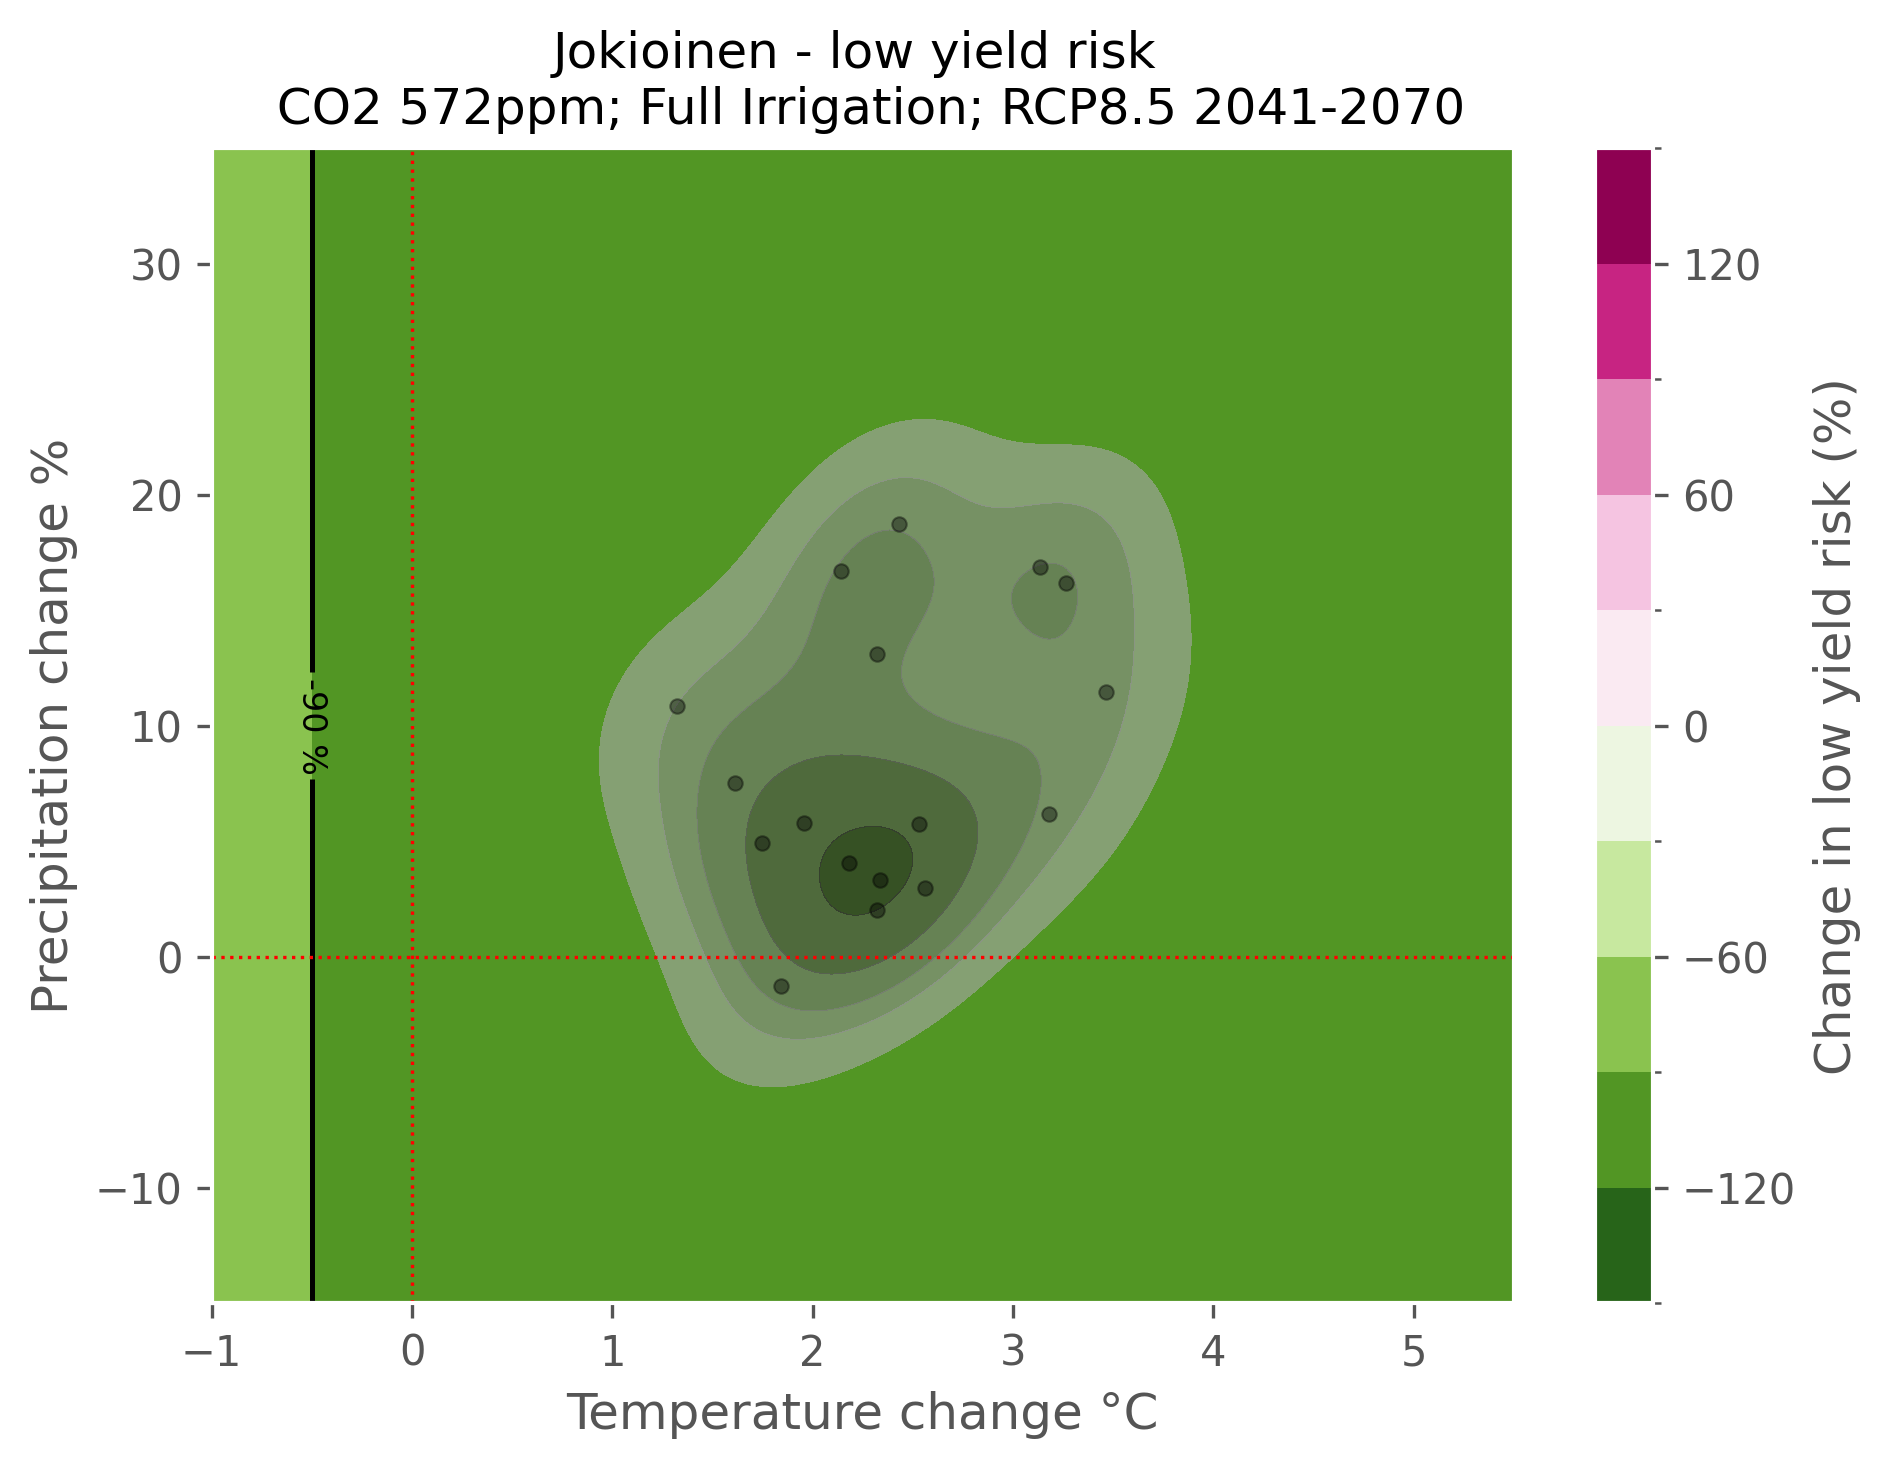

In [275]:
# Filled contour plot (smooth shading)
plt.figure(figsize=(7,5), dpi = 300)
contourf = data2.plot.contourf(levels=11, cmap='PiYG_r', 
                              vmin = -150,
                              vmax = +150, #vmax= 7900,
                              cbar_kwargs={'label': 'Change in low yield risk (%)'})  # more levels = smoother
# Define contour levels
levels = np.linspace(-150, 150, 11)

# Default all black
colors = ["black"] * len(levels)

# If 0 is in levels, make it red
if 0 in levels:
    idx0 = list(levels).index(0)
    colors[idx0] = "red"
else:
    # Ensure 0 is included
    levels = np.sort(np.append(levels, 0))
    colors = ["black"] * len(levels)
    colors[list(levels).index(0)] = "red"

# Add isolines
contour = data2.plot.contour(
    levels=levels,
    colors=colors,
    linewidths=1.2,
    linestyles='-',
    add_labels=False   # turn off auto-labels
)

# Label isolines with % sign
plt.clabel(
    contour,
    inline=True,
    fontsize=8,
    fmt='%1.0f %%'   # format labels as integers with % sign
)

plt.xlabel("Temperature change °C")
plt.ylabel("Precipitation change %")
plt.title(title_plot, fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

if show_climate:
    # KDE shading
    # Truncate the Greys colormap to avoid white
    def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
        return LinearSegmentedColormap.from_list(
            "trunc_greys", cmap(np.linspace(minval, maxval, n))
        )
    trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
    ax = sns.kdeplot(
        x=df_changes['t_change'],
        y=df_changes['pp_change'],
        cmap=trunc_greys,   # use truncated greys
        fill=True, alpha=0.6,
        levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
        thresh=0.0,
        common_norm=False
    )

    # --- Overlay CSV points ---
    plt.scatter(
        df_changes['t_change'],   # x-axis: temperature change
        df_changes['pp_change'],  # y-axis: precipitation change
        color="k", edgecolor="k", s=12, marker="o", alpha=0.4
    )

    # Add colorbar for probability scale
    # norm = plt.Normalize(vmin=0, vmax=1)
    # sm = plt.cm.ScalarMappable(cmap="Greys", norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax)
    # cbar.set_label("Probability density (cumulative)")

# --- Add reference lines ---
plt.axhline(y=0, color='red', linestyle=':', linewidth=0.8)  # horizontal line at PP change = 0
plt.axvline(x=0, color='red', linestyle=':', linewidth=0.8)  # vertical line at T change = 0

plt.ylim(-15, 35)
plt.xlim(-1, 5.5)
plt.title(title_plot2, fontsize=12)
# Add grid
plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
plt.savefig(plot_name2, dpi=300)
plt.show()

In [ ]:
# title = 'Jokioinen - Yield reliability \n Adapted cultivar; Clay soil; CO2 498ppm; Adapted sowing date; RCP4.5 2041-2070'

# # Yield reliability in % defined as the percentage of years when DM grain yield (kg ha−1) is above the 10th percentile of the baseline yield
# # 1. Compute the 10th percentile of baseline yields across years 
# baseline_threshold = max_per_year_base.quantile(0.10, dim="year") 
# #2. Compare each year’s yield against the threshold # This gives a boolean DataArray (True if yield >= threshold) 
# above_threshold = max_per_year >= baseline_threshold 
# # 3. Compute reliability as percentage of years above threshold 
# reliability = above_threshold.mean(dim="year") * 100.0

# #data = diff.mean(dim='year')  #max_per_year.mean(dim='year') 
# data = reliability.copy()  #max_per_year.mean(dim='year') 

# # Filled contour plot (smooth shading)
# plt.figure(figsize=(8,5), dpi = 300)
# contourf = data.plot.contourf(levels=12, cmap='YlGn', 
#                               vmin = 60,
#                               vmax = 100, #vmax= 7900,
#                               cbar_kwargs={'label': 'Yield reliability (%)'})  # more levels = smoother
# # Define contour levels
# levels = np.arange(60, 105, 5)

# # Default all black
# colors = ["black"] * len(levels)

# # If 0 is in levels, make it red
# if 0 in levels:
#     idx0 = list(levels).index(0)
#     colors[idx0] = "red"
# else:
#     # Ensure 0 is included
#     levels = np.sort(np.append(levels, 0))
#     colors = ["black"] * len(levels)
#     colors[list(levels).index(0)] = "red"

# # Add isolines
# contour = data.plot.contour(
#     levels=levels,
#     colors=colors,
#     linewidths=1.2,
#     linestyles='-',
#     add_labels=False   # turn off auto-labels
# )

# # Label isolines with % sign
# plt.clabel(
#     contour,
#     inline=True,
#     fontsize=8,
#     fmt='%1.0f %%'   # format labels as integers with % sign
# )

# plt.xlabel("Temperature change °C")
# plt.ylabel("Precipitation change %")
# plt.title(title, fontsize=12)
# plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)

# if show_climate:
#     # KDE shading
#     # Truncate the Greys colormap to avoid white
#     def truncate_colormap(cmap, minval=0.4, maxval=0.9, n=100):
#         return LinearSegmentedColormap.from_list(
#             "trunc_greys", cmap(np.linspace(minval, maxval, n))
#         )
#     trunc_greys = truncate_colormap(plt.cm.Greys, 0.4, 0.9)
#     ax = sns.kdeplot(
#         x=df_changes['t_change'],
#         y=df_changes['pp_change'],
#         cmap=trunc_greys,   # use truncated greys
#         fill=True, alpha=0.6,
#         levels=[0.1, 0.25, 0.5, 0.75, 0.95, 1],
#         thresh=0.0,
#         common_norm=False
#     )

#     # --- Overlay CSV points ---
#     plt.scatter(
#         df_changes['t_change'],   # x-axis: temperature change
#         df_changes['pp_change'],  # y-axis: precipitation change
#         color="k", edgecolor="k", s=12, marker="o", alpha=0.4
#     )

#     # Add colorbar for probability scale
#     # norm = plt.Normalize(vmin=0, vmax=1)
#     # sm = plt.cm.ScalarMappable(cmap="Greys", norm=norm)
#     # sm.set_array([])
#     # cbar = plt.colorbar(sm, ax=ax)
#     # cbar.set_label("Probability density (cumulative)")

# # --- Add reference lines ---
# plt.axhline(y=0, color='red', linestyle=':', linewidth=0.8)  # horizontal line at PP change = 0
# plt.axvline(x=0, color='red', linestyle=':', linewidth=0.8)  # vertical line at T change = 0

# plt.ylim(-15, 35)
# plt.xlim(-1, 5.5)
# plt.title(title, fontsize=12)
# # Add grid
# plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
# #plt.savefig("Jokioinen_SpringWheat_Calibrated_ClaySoil_CO2422ppm_FixedSowingDate.png", dpi=300)
# plt.savefig("Jokioinen_SpringWheat_Adapted_ClaySoil_CO2498ppm_AdaptedSowingDate_RCP4.5_midCent.png", dpi=300)
# plt.show()

: 

In [276]:
results_data_file_rainfed = "all_results_SoilFIN_CLAY_1_CO2422.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB_IrrigationRAINFED.pkl"
results_data_file_full = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB_IrrigationFULL.pkl"
results_data_file_si = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB_IrrigationSI.pkl"
#results_data_file_adapted3 = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateTrue_Fertilization100_CropFilespringwheat_calibrated_adapted3_WOFOST81_WLP_MLWB.pkl"

#with open(results_data_file_adapted3, "rb") as f:
 #  all_results_adapted3 =  pickle.load(f)
#wsoIRS_adapted3 = wso_cube_from_results(all_results_adapted3)

with open(results_data_file_rainfed, "rb") as f:
   all_results_rainfed =  pickle.load(f)
wsoIRS_rainfed = wso_cube_from_results(all_results_rainfed)

with open(results_data_file_full, "rb") as f:
   all_results_full =  pickle.load(f)
wsoIRS_full = wso_cube_from_results(all_results_full)

with open(results_data_file_si, "rb") as f:
   all_results_si =  pickle.load(f)
wsoIRS_si = wso_cube_from_results(all_results_si)


In [88]:
wsoIRS_rainfed.sel(Tstep=Tstep, PPstep=PPstep)

<xarray.Dataset> Size: 92kB
Dimensions:  (day: 5733)
Coordinates:
  * day      (day) datetime64[ns] 46kB 1991-03-01 1991-03-02 ... 2020-09-15
    PPstep   float64 8B 10.0
    Tstep    float64 8B 0.0
Data variables:
    WSO      (day) float64 46kB nan nan nan nan nan nan ... nan nan nan nan nan

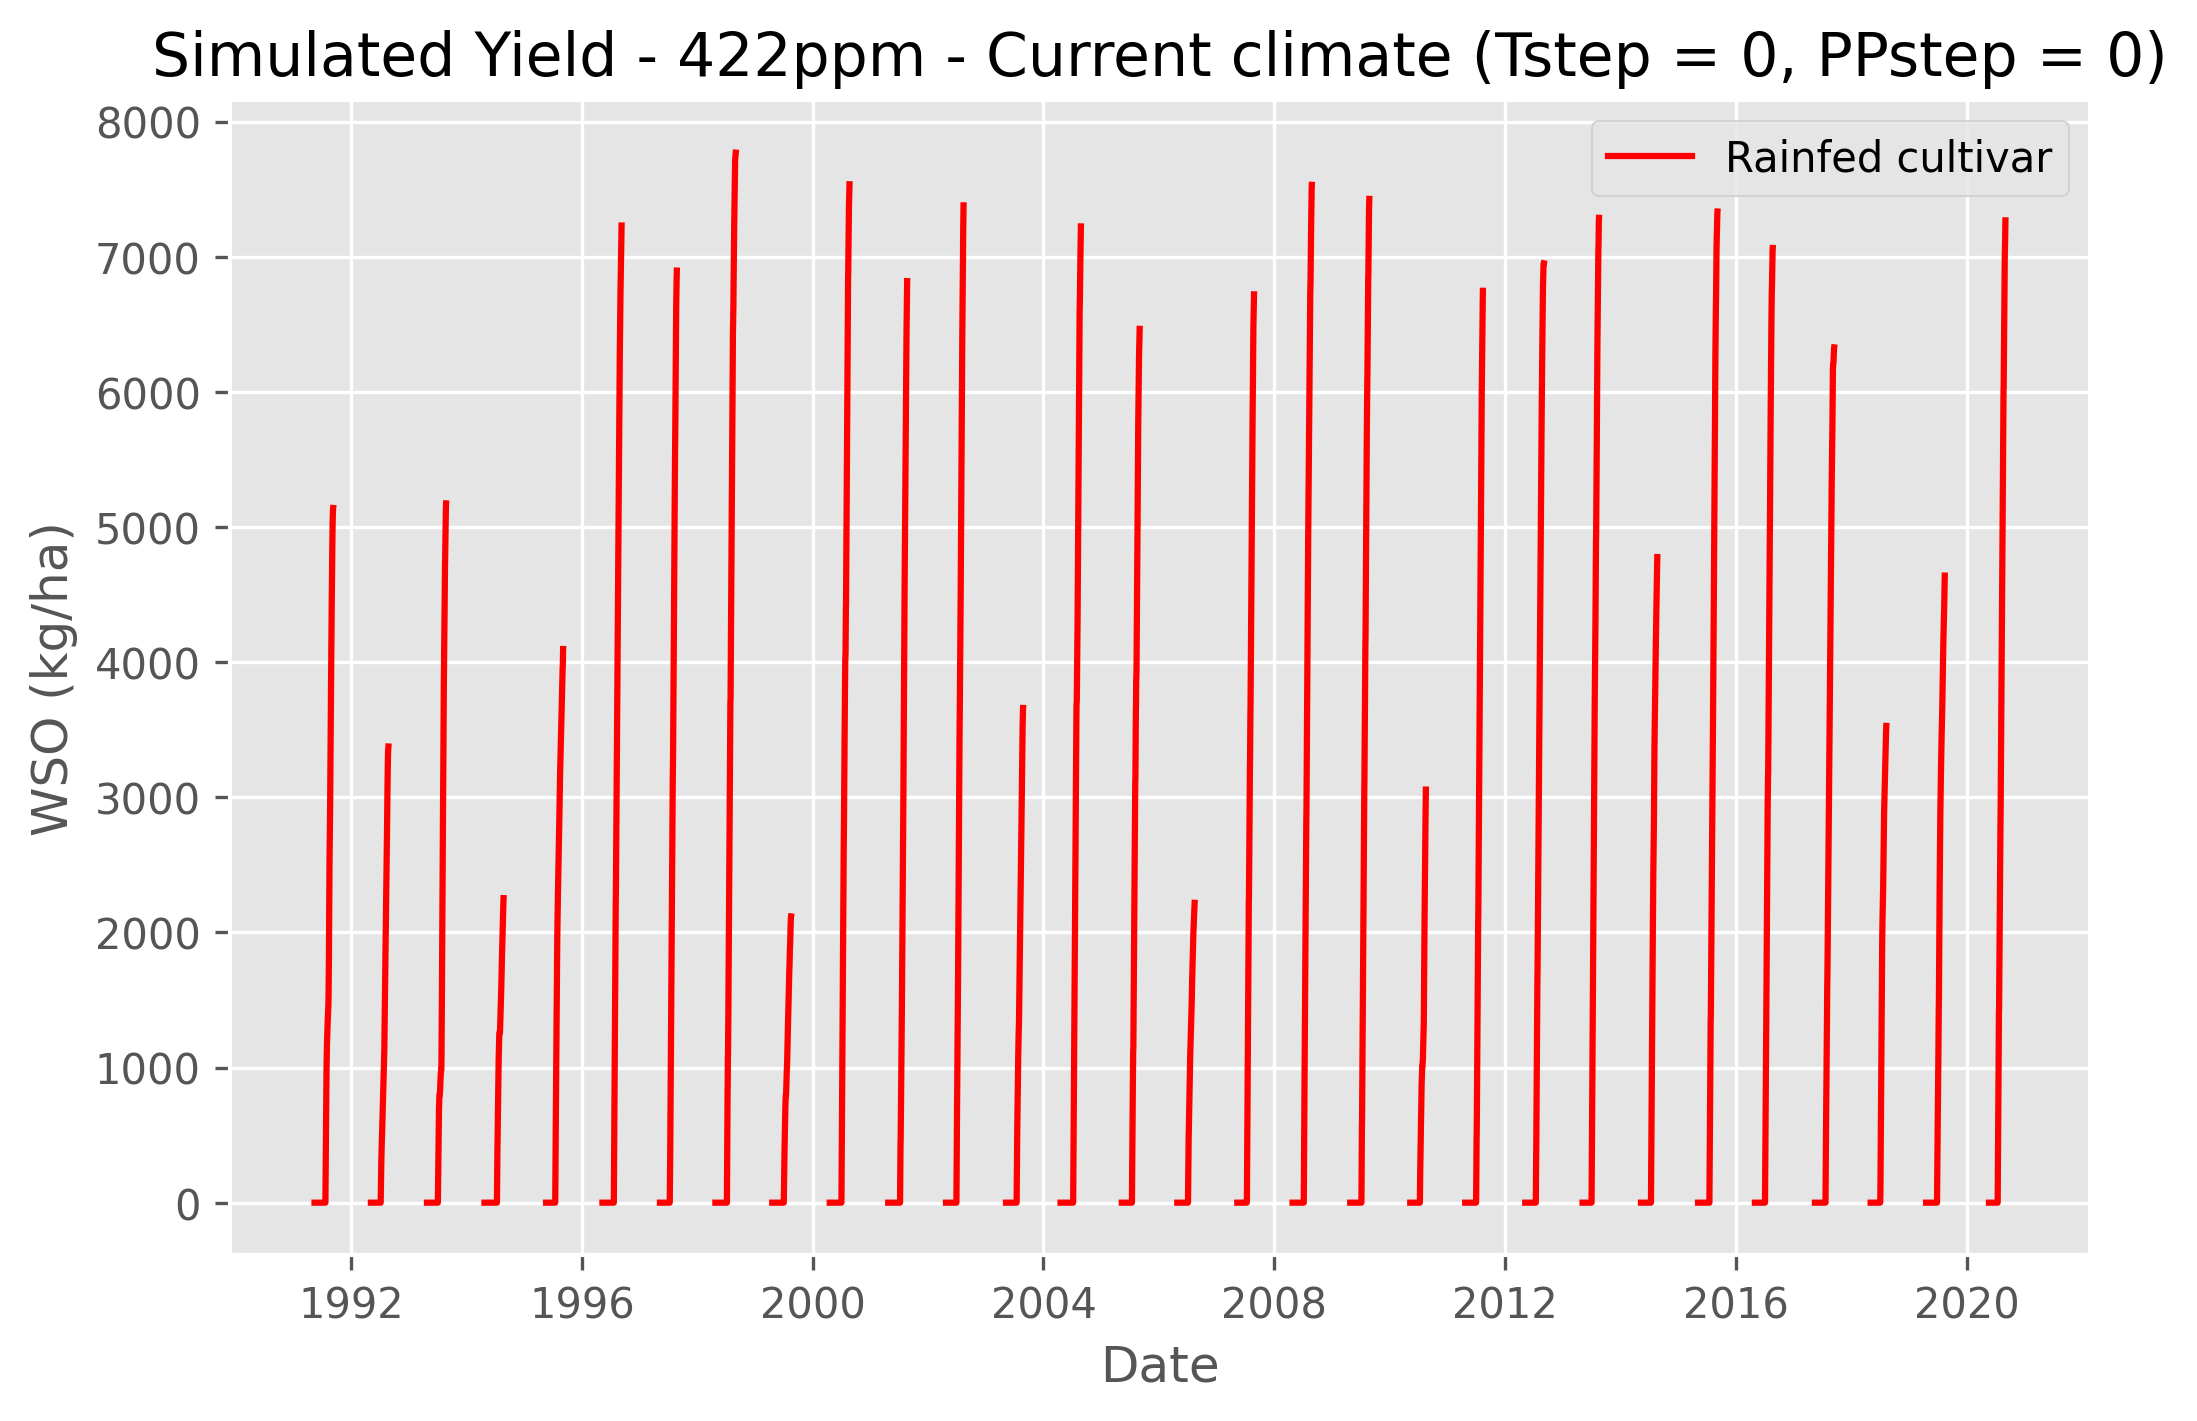

In [280]:
Tstep = 0
PPstep = 0
plt.figure(figsize=(8,5), dpi = 300)
#plt.plot(wsoIRS_full.sel(Tstep=Tstep, PPstep=PPstep)["day"], wsoIRS_full.sel(Tstep=Tstep, PPstep=PPstep)["WSO"], label='Full irrigation cultivar', linestyle='-', c = 'r')
#plt.plot(wsoIRS_si.sel(Tstep=Tstep, PPstep=PPstep)["day"], wsoIRS_si.sel(Tstep=Tstep, PPstep=PPstep)["WSO"], label='Supplementary irrigation cultivar', linestyle='--', c = 'g')
plt.plot(wsoIRS_rainfed.sel(Tstep=Tstep, PPstep=PPstep)["day"], wsoIRS_rainfed.sel(Tstep=Tstep, PPstep=PPstep)["WSO"], label='Rainfed cultivar', c = 'r')
plt.title(f'Simulated Yield - 422ppm - Current climate (Tstep = {Tstep}, PPstep = {PPstep})')
plt.xlabel('Date')
plt.ylabel('WSO (kg/ha)')
plt.legend()

In [ ]:
# check with other soil type
# try with one year and one weather file

In [ ]:
results_data_file_current = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateTrue_Fertilization100_CropFilespringwheat_calibrated_WOFOST81_WLP_MLWB.pkl"
results_data_file_adapted = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateTrue_Fertilization100_CropFilespringwheat_calibrated_adapted_WOFOST81_WLP_MLWB.pkl"
results_data_file_adapted2 = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateTrue_Fertilization100_CropFilespringwheat_calibrated_adapted2_WOFOST81_WLP_MLWB.pkl"
results_data_file_adapted3 = "all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateTrue_Fertilization100_CropFilespringwheat_calibrated_adapted3_WOFOST81_WLP_MLWB.pkl"

with open(results_data_file_adapted3, "rb") as f:
   all_results_adapted3 =  pickle.load(f)
wsoIRS_adapted3 = wso_cube_from_results(all_results_adapted3)

with open(results_data_file_adapted2, "rb") as f:
   all_results_adapted2 =  pickle.load(f)
wsoIRS_adapted2 = wso_cube_from_results(all_results_adapted2)

with open(results_data_file_adapted, "rb") as f:
   all_results_adapted =  pickle.load(f)
wsoIRS_adapted = wso_cube_from_results(all_results_adapted)

with open(results_data_file_current, "rb") as f:
   all_results_current =  pickle.load(f)
wsoIRS_current = wso_cube_from_results(all_results_current)



: 

current 1008.379688088474
adapted 1034.1950326101328
base 1317.1088960390803
current vs base % diff: -23.439915171709984
adapted vs base % diff: -21.479914400377194
current max mean 4099.101630409739
adapted max mean 3769.6854594123174
base max mean 5444.911805894881
current vs base  diff: -24.71684066632839
adapted vs base  diff: -30.76682242435765


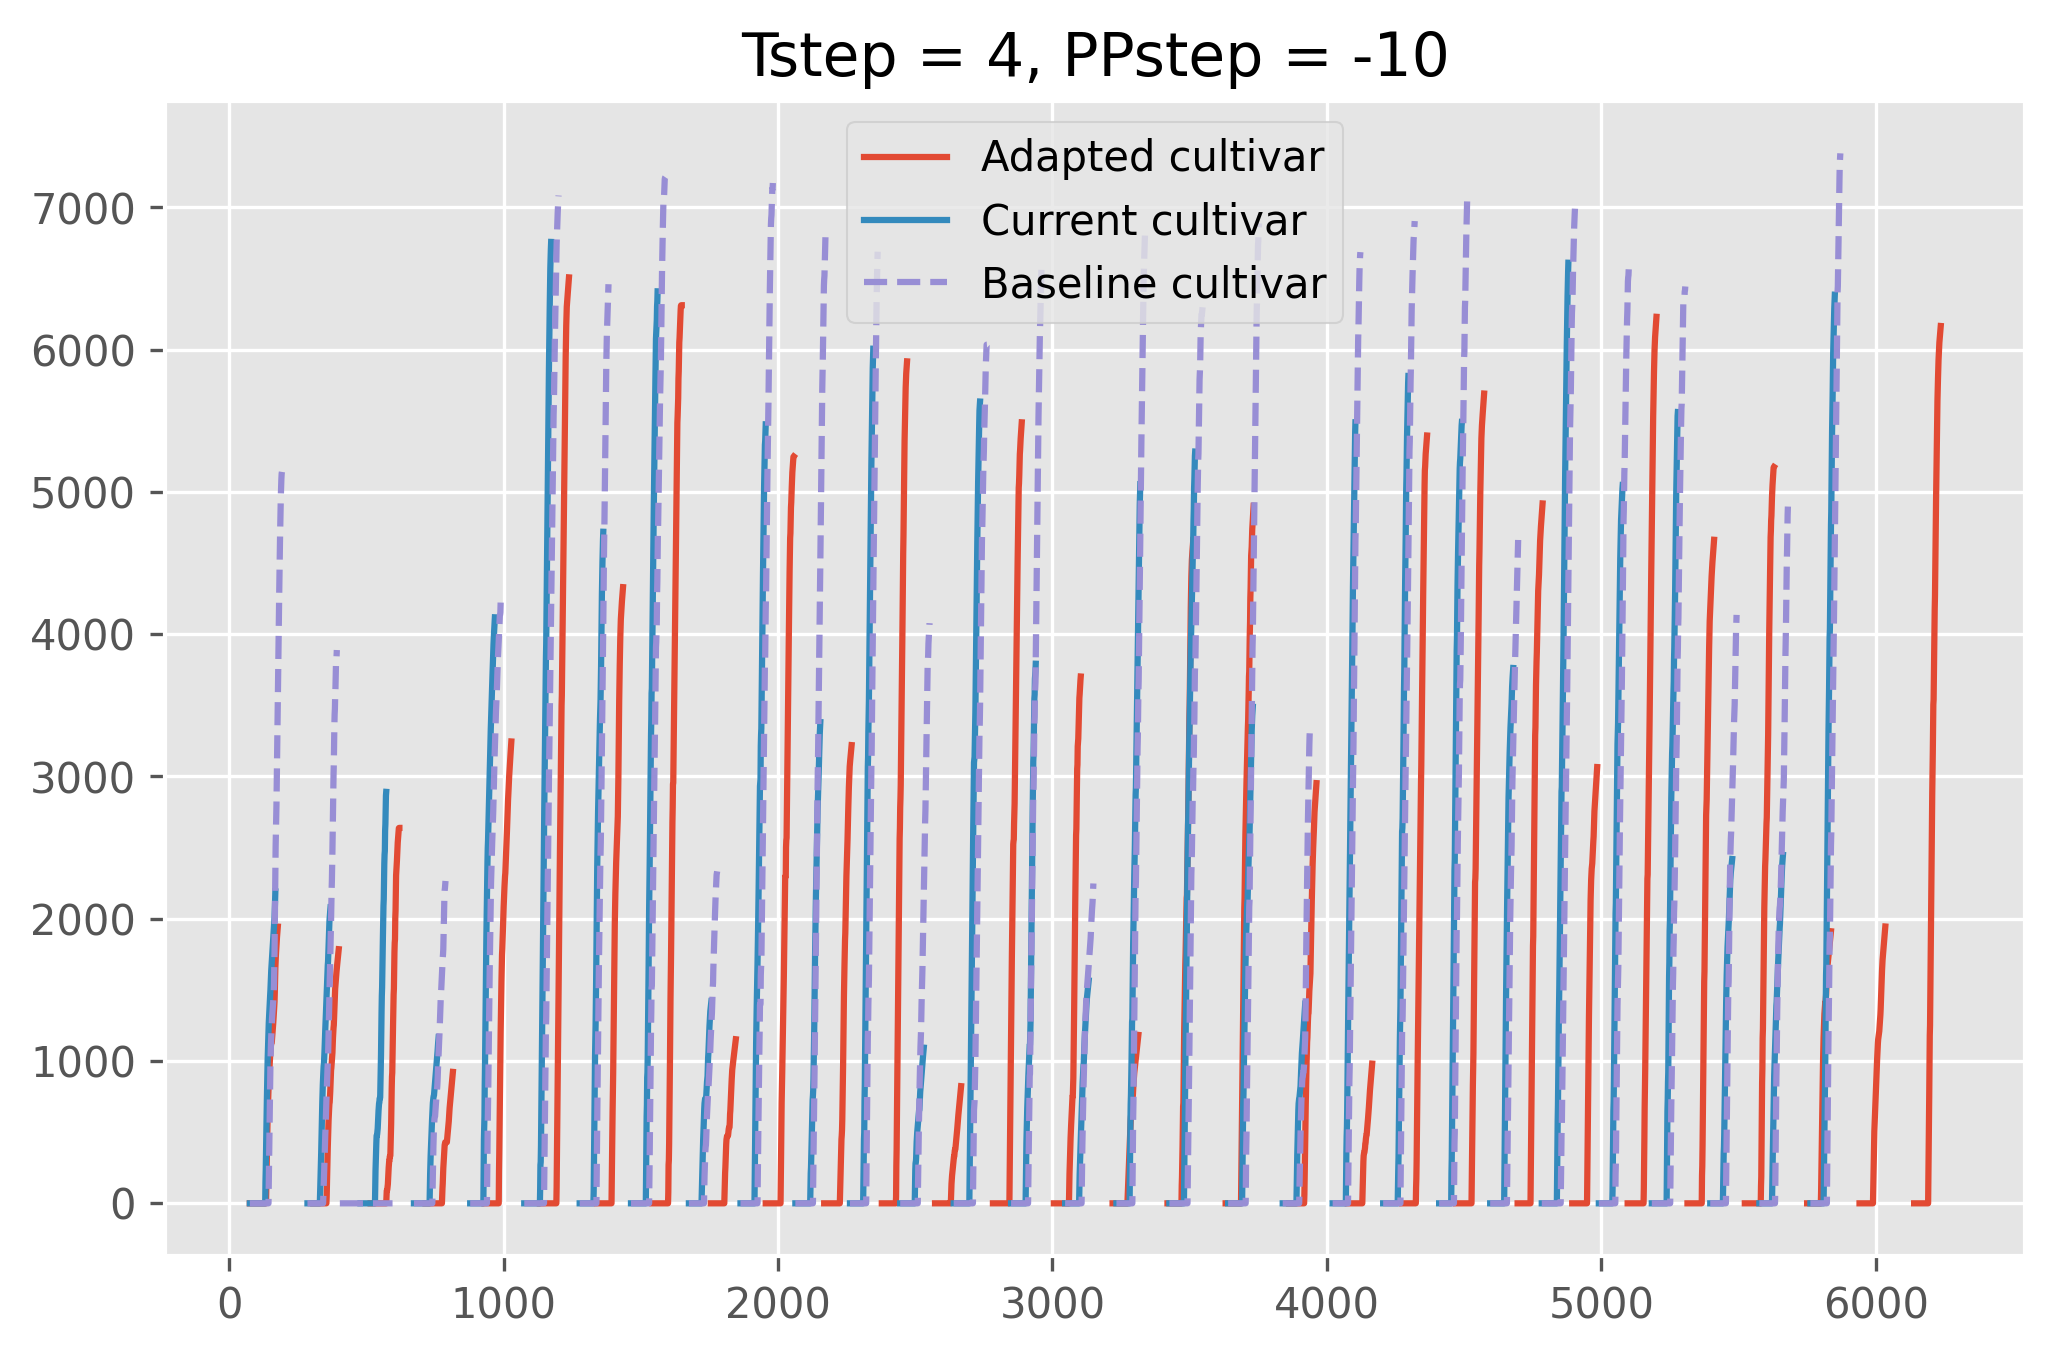

: 

In [ ]:
Tstep = 4
PPstep = -10
plt.figure(figsize=(8,5), dpi = 300)
#plt.plot(wsoIRS_adapted3["WSO"].sel(Tstep=Tstep, PPstep=PPstep), label='Adapted cultivar 3')
#plt.plot(wsoIRS_adapted2["WSO"].sel(Tstep=Tstep, PPstep=PPstep), label='Adapted cultivar 2')
plt.plot(wsoIRS_adapted["WSO"].sel(Tstep=Tstep, PPstep=PPstep), label='Adapted cultivar')
plt.plot(wsoIRS_current["WSO"].sel(Tstep=Tstep, PPstep=PPstep), label='Current cultivar')
plt.plot(wsoIRS_base["WSO"].sel(Tstep=0, PPstep=0), label='Baseline cultivar', linestyle='--')
plt.title(f'Tstep = {Tstep}, PPstep = {PPstep}')
plt.legend()



current = np.mean(wsoIRS_current["WSO"].sel(Tstep=Tstep, PPstep=PPstep)).values
adapted = np.mean(wsoIRS_adapted["WSO"].sel(Tstep=Tstep, PPstep=PPstep)).values
base = np.mean(wsoIRS_base["WSO"].sel(Tstep=0, PPstep=0)).values
print('current', current)
print('adapted', adapted)
print('base', base) 

print('current vs base % diff:', (current - base) / base * 100)
print('adapted vs base % diff:', (adapted - base) / base * 100)


#same with the maximum yield of each year
max_per_year_base = wsoIRS_base['WSO'].groupby('day.year').max() # Group by year and take the maximum
max_per_year_current = wsoIRS_current['WSO'].groupby('day.year').max() # Group by year and take the maximum
max_per_year_adapted = wsoIRS_adapted['WSO'].groupby('day.year').max() # Group by year and take the maximum

base_max = max_per_year_base.sel(Tstep=0, PPstep=0).values
current_max = max_per_year_current.sel(Tstep=Tstep, PPstep=PPstep).values
adapted_max = max_per_year_adapted.sel(Tstep=Tstep, PPstep=PPstep).values

print('current max mean', np.mean(current_max))
print('adapted max mean', np.mean(adapted_max))
print('base max mean', np.mean(base_max))
#print('adapted_max', adapted_max)
#print('current_max', current_max)
print('current vs base  diff:', (np.mean(current_max) - np.mean(base_max)) / np.mean(base_max) * 100)
print('adapted vs base  diff:', (np.mean(adapted_max) - np.mean(base_max)) / np.mean(base_max) * 100)

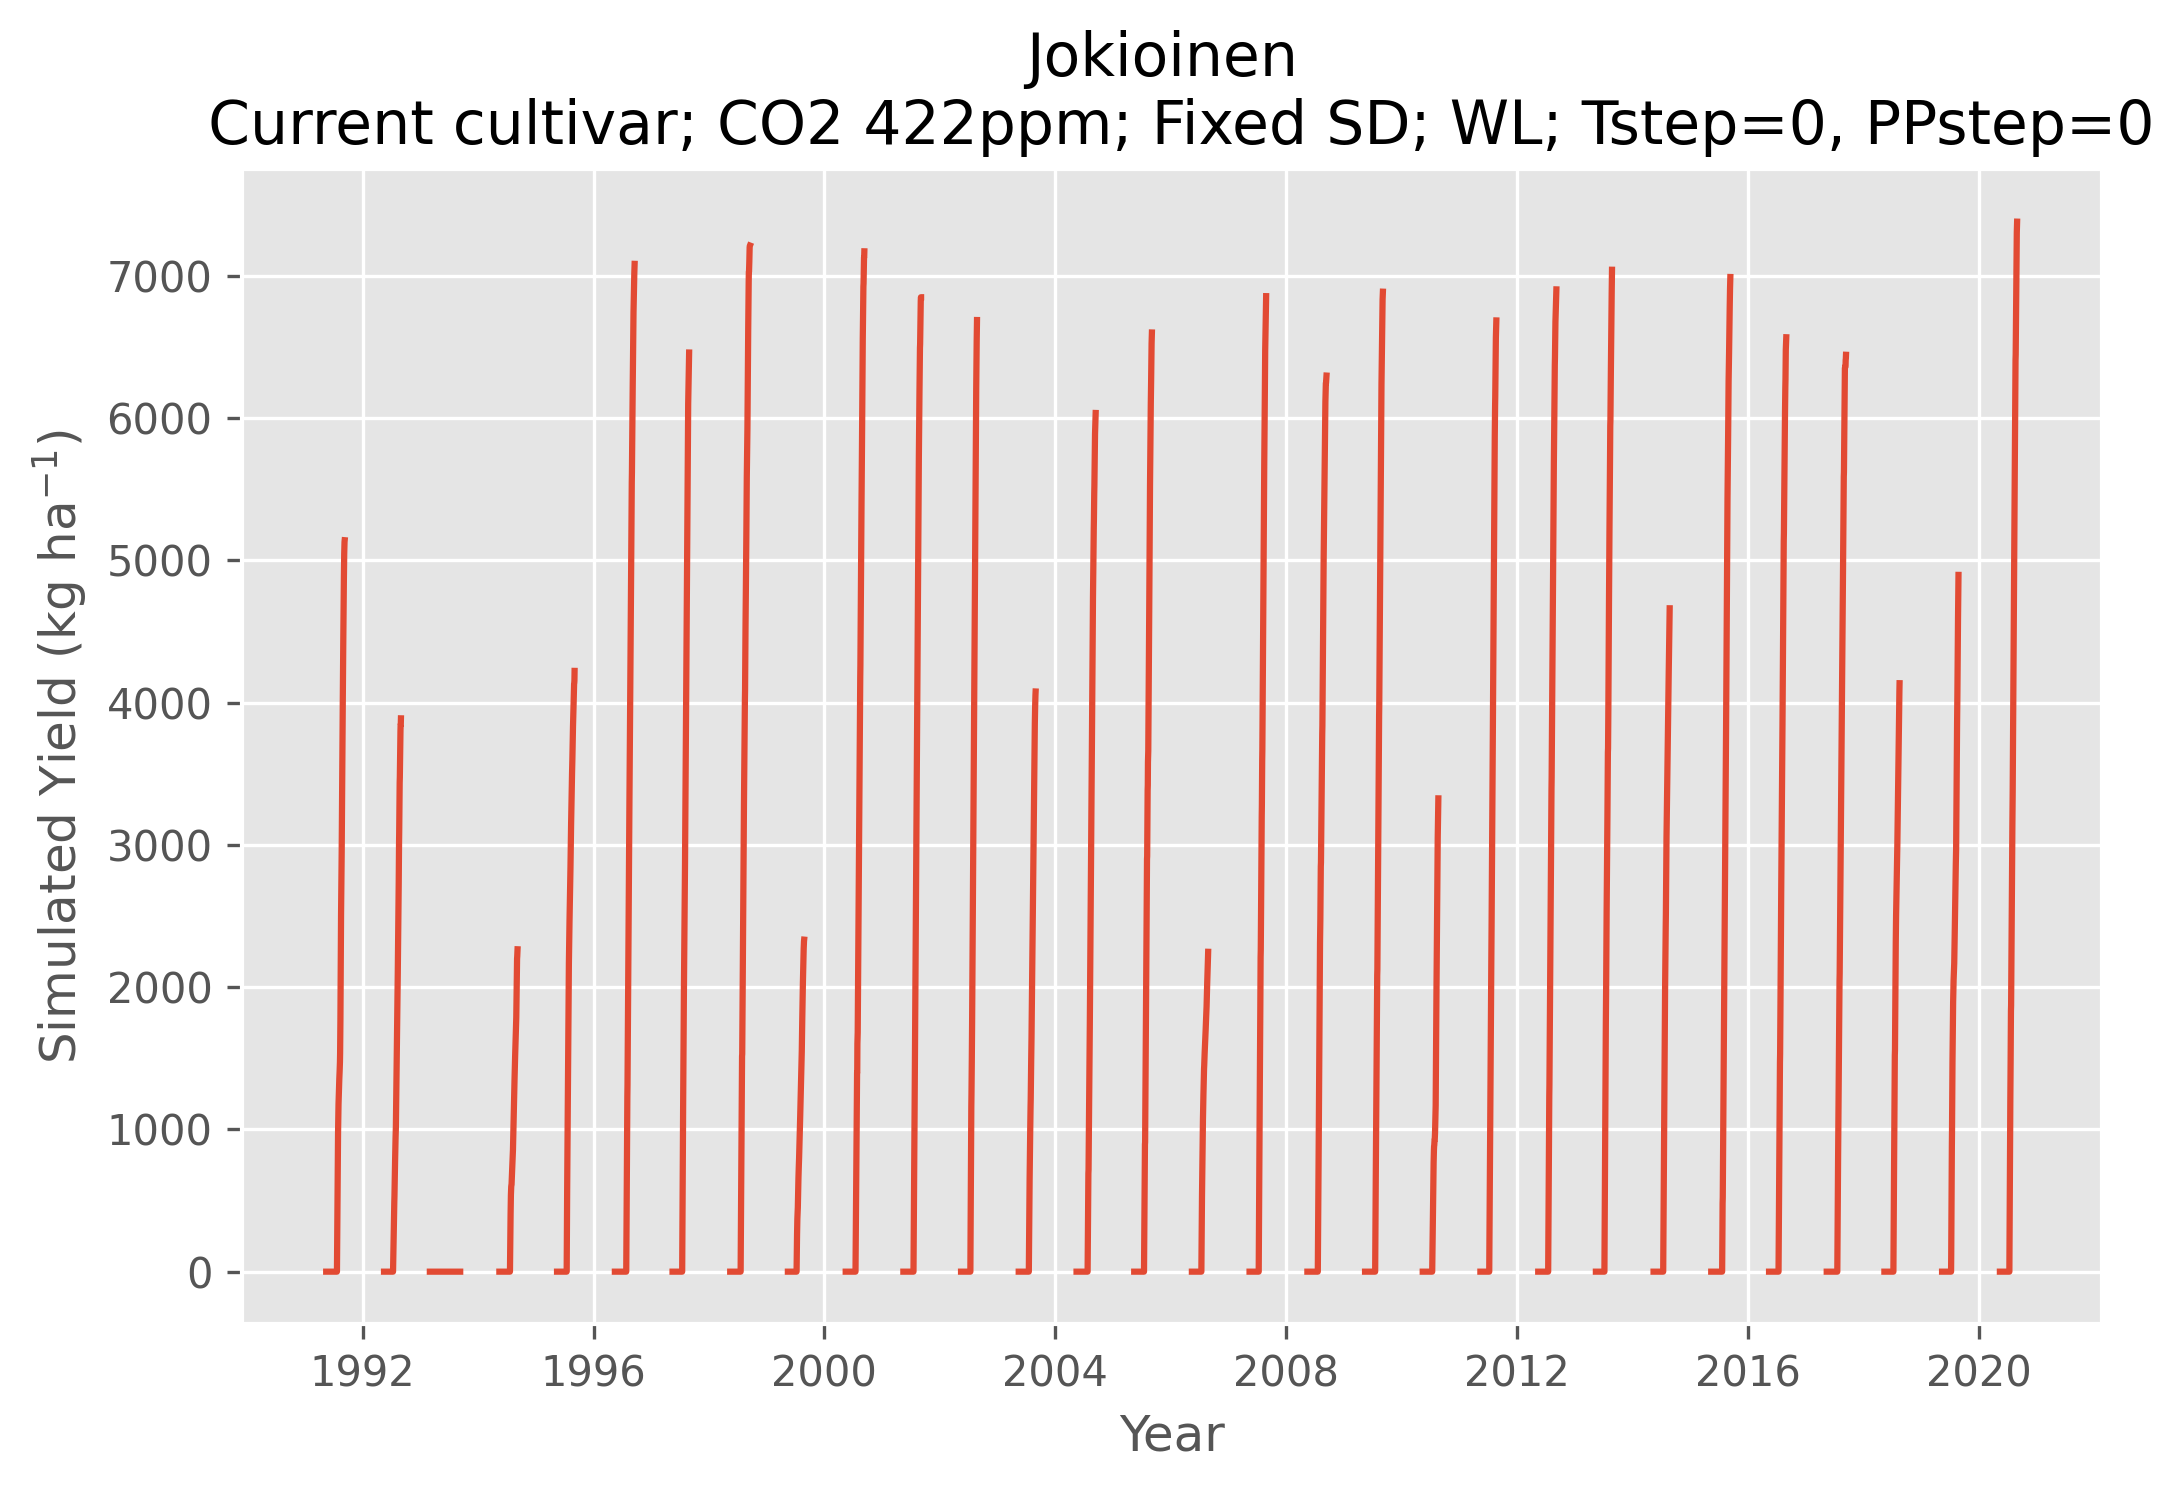

: 

In [ ]:
title_plot = 'Jokioinen \n Current cultivar; CO2 422ppm; Fixed SD; WL; Tstep=0, PPstep=0'
plot_name = "Jokioinen_Currentcultivar_CO2422ppm_FixedSD_WLmodel_Tstep0PPstep0_timeserie.png"

# Select the slice at Tstep=0 and PPstep=0
data_slice = wsoIRS_base.sel(Tstep=0, PPstep=0)

plt.figure(figsize=(8,5), dpi = 300)
# Plot all variables in that slice against 'day'
data_slice.to_array().plot.line(x='day',add_legend=False)
plt.title(title_plot)
plt.xlabel("Year")
plt.ylabel("Simulated Yield (kg ha$^{-1}$)")
plt.savefig(plot_name)
plt.show()


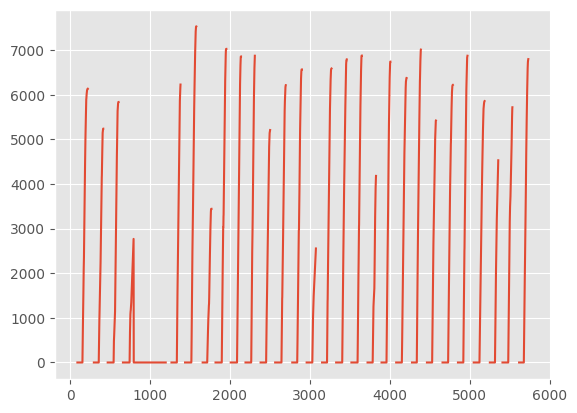

: 

: 

: 

: 

: 

: 

In [ ]:
with open("all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated.pkl", "rb") as f:
   all_results =  pickle.load(f)


wsoIRS_current = wso_cube_from_results(all_results)

plt.plot(wsoIRS_current["WSO"].sel(Tstep=-1, PPstep=0))

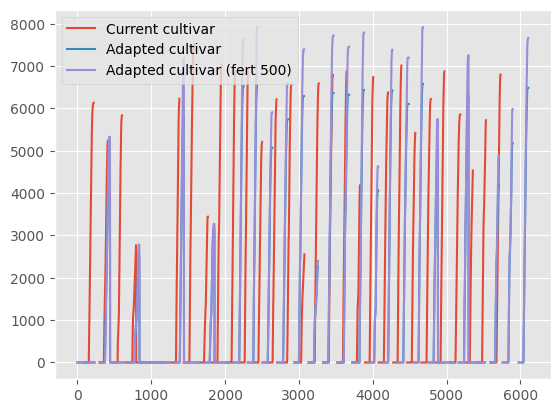

: 

: 

: 

: 

: 

: 

In [ ]:
with open("all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateFalse_Fertilization100_CropFilespringwheat_calibrated_adapted.pkl", "rb") as f:
   all_results =  pickle.load(f)
wsoIRS_adapted = wso_cube_from_results(all_results)

with open("all_results_SoilFIN_CLAY_1_CO2498.0_FixedSowingDateFalse_Fertilization500_CropFilespringwheat_calibrated_adapted.pkl", "rb") as f:
   all_results =  pickle.load(f)
wsoIRS_adapted_fert500 = wso_cube_from_results(all_results)

plt.plot(wsoIRS_current["WSO"].sel(Tstep=-1, PPstep=0), label = 'Current cultivar')
plt.plot(wsoIRS_adapted["WSO"].sel(Tstep=-1, PPstep=0), label = 'Adapted cultivar')
plt.plot(wsoIRS_adapted_fert500["WSO"].sel(Tstep=-1, PPstep=0), label = 'Adapted cultivar (fert 500)')
plt.legend()


: 

: 

: 

: 

: 

: 

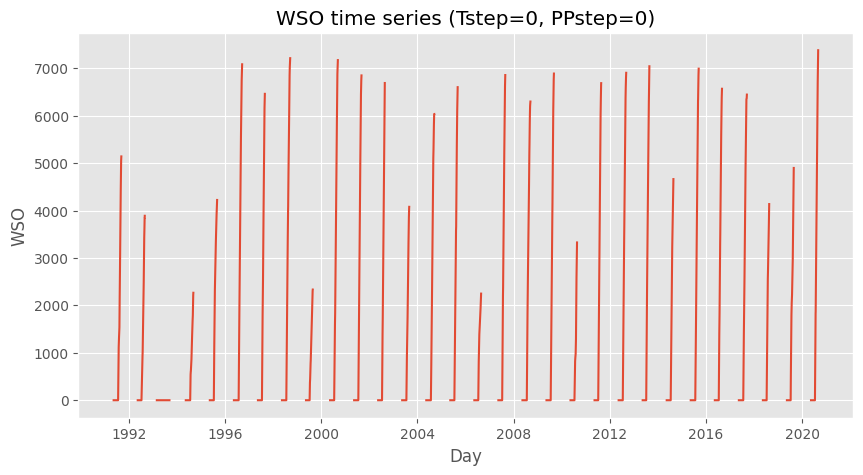

: 

: 

: 

: 

: 

: 

In [ ]:
sel_ds = wsoIRS["WSO"].sel(Tstep=0, PPstep=0)

# Plot the time series
plt.figure(figsize=(10,5))
sel_ds.plot()
plt.title("WSO time series (Tstep=0, PPstep=0)")
plt.ylabel("WSO")
plt.xlabel("Day")
plt.grid(True)
plt.show()

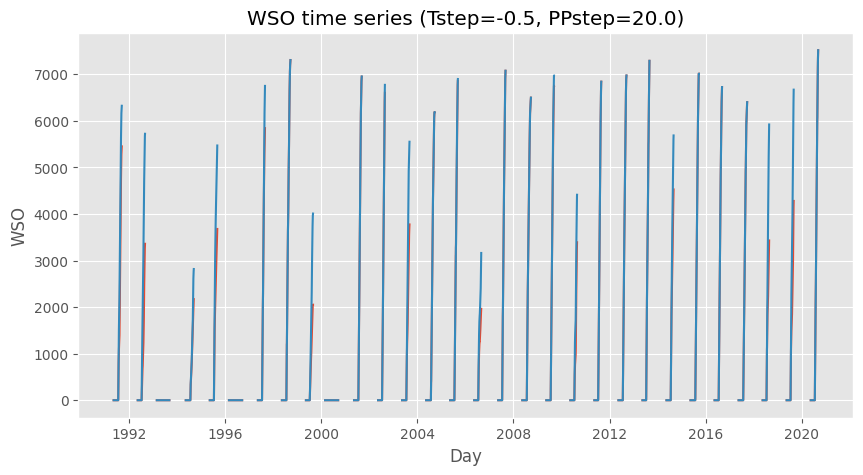

: 

: 

: 

: 

: 

: 

In [ ]:
sel_ds = wsoIRS["WSO"].sel(Tstep=-0.5, PPstep=-15.0)
sel_ds2 = wsoIRS["WSO"].sel(Tstep=-0.5, PPstep=25.0)

# Plot the time series
plt.figure(figsize=(10,5))
sel_ds.plot()
sel_ds2.plot()
plt.title("WSO time series (Tstep=-0.5, PPstep=20.0)")
plt.ylabel("WSO")
plt.xlabel("Day")
plt.grid(True)
plt.show()

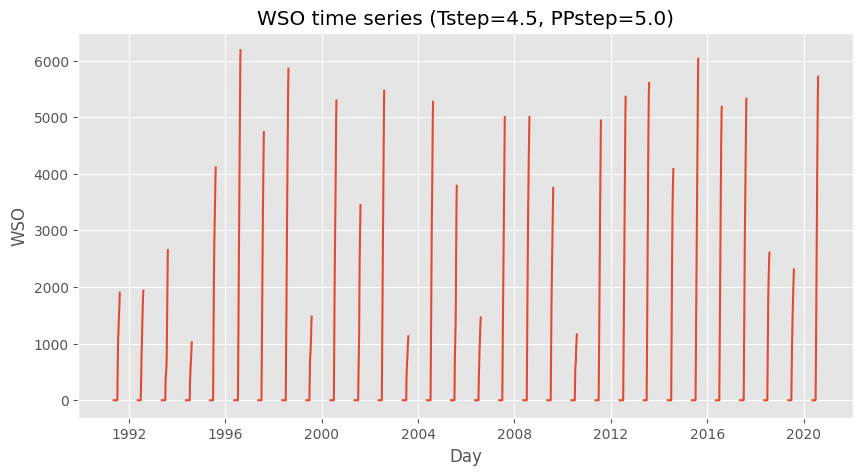

: 

: 

: 

: 

: 

: 

In [ ]:
sel_ds = wsoIRS["WSO"].sel(Tstep=4.5, PPstep=5.0)

# Plot the time series
plt.figure(figsize=(10,5))
sel_ds.plot()
plt.title("WSO time series (Tstep=4.5, PPstep=5.0)")
plt.ylabel("WSO")
plt.xlabel("Day")
plt.grid(True)
plt.show()

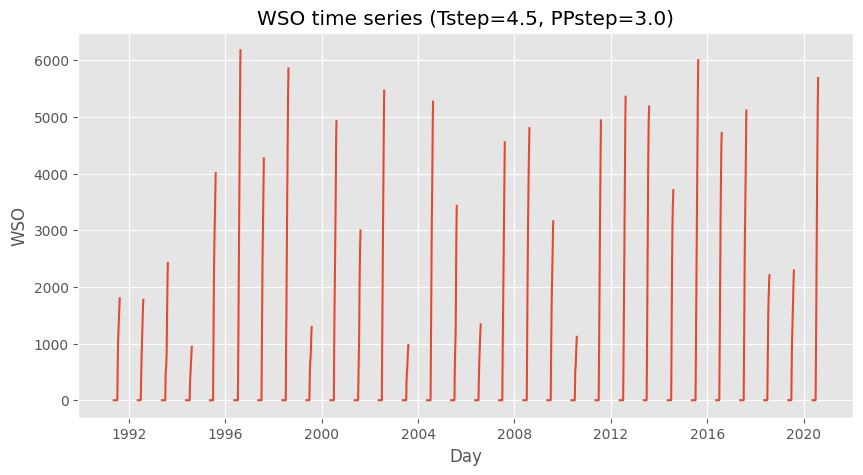

: 

: 

: 

: 

: 

: 

In [ ]:
sel_ds = wsoIRS["WSO"].sel(Tstep=4.5, PPstep=-5.0)

# Plot the time series
plt.figure(figsize=(10,5))
sel_ds.plot()
plt.title("WSO time series (Tstep=4.5, PPstep=3.0)")
plt.ylabel("WSO")
plt.xlabel("Day")
plt.grid(True)
plt.show()

In [ ]:
wsoIRS[]

SyntaxError: invalid syntax (2395706177.py, line 1)

: 

: 

: 

: 

: 

: 

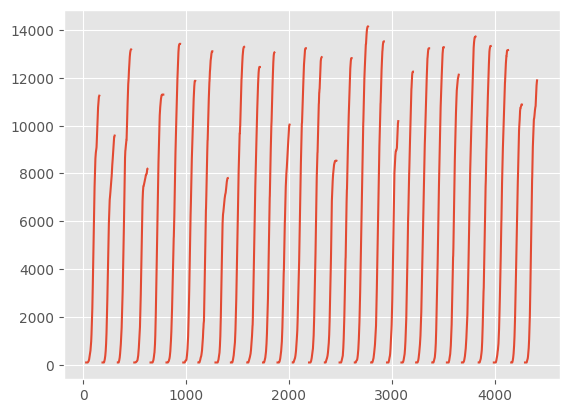

: 

: 

: 

: 

: 

: 

In [ ]:
plt.plot(outputs_df['TAGP'], label='Total above ground biomass (TAGP)')

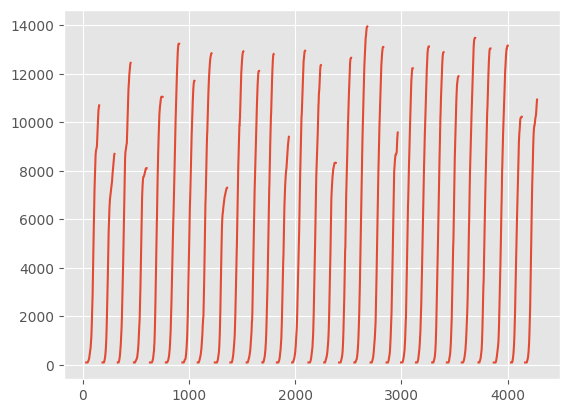

: 

: 

: 

: 

: 

: 

In [ ]:
plt.plot(outputs_df['TAGP'], label='Total above ground biomass (TAGP)')

In [ ]:
#upload weather file 
#get list of .csv in the folder data/met2015Sensivity/lagged



    #run long term wofost simulation
    #use the above 
    #save it into a netcdf file

#save netcdf file 


: 

: 

: 

: 

: 

: 